In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pprint
import networkx as nx
import statistics

if os.path.isdir("../data/"):
    os.chdir("../")

%load_ext autoreload
%autoreload 2

from src.plots_utils import get_plt_attr, get_politic_news_color_maps, get_parties_color_maps
from src.utils import *


rcParams, column_width, page_width, shorts_style, RV_style = get_plt_attr()
plt.rcParams.update(rcParams)

party_colors = get_parties_color_maps()

In [2]:
stat_not_significant_channels = ['Gabriel Attal', 'LP', 'LR', 'RE', 'Rima Hassan', 'UDI']

In [3]:
yt_nm_videos_2022 = pd.read_json("data/youtube/videos/news_videos_2022.jsonl", lines=True)
yt_nm_videos_2024 = pd.read_json("data/youtube/videos/news_videos_2024.jsonl", lines=True)
yt_pp_videos_2022 = pd.read_json("data/youtube/videos/pp_videos_2022.jsonl", lines=True)
yt_pp_videos_2024 = pd.read_json("data/youtube/videos/pp_videos_2024.jsonl", lines=True)
for yt_df in [yt_nm_videos_2022, yt_nm_videos_2024, yt_pp_videos_2022, yt_pp_videos_2024]:
    yt_df['publishedAt'] = pd.to_datetime(yt_df['publishedAt'])

In [4]:
nm_name_standard_list = yt_nm_videos_2024['name_standard'].unique()
pp_name_standard_list = list(set(yt_pp_videos_2024['name_standard'].unique()) - set(stat_not_significant_channels))

In [5]:
videoId2yt_type = dict(zip(yt_nm_videos_2022['videoId'], ["Short"  if e==True else "RV" for e in list(yt_nm_videos_2022['isShort'])]))
videoId2yt_type.update(dict(zip(yt_nm_videos_2024['videoId'], 
                                ["Short"  if e==True else "RV" for e in list(yt_nm_videos_2024['isShort'])])))
videoId2yt_type.update(dict(zip(yt_pp_videos_2022['videoId'], 
                                ["Short"  if e==True else "RV" for e in list(yt_pp_videos_2022['isShort'])])))
videoId2yt_type.update(dict(zip(yt_pp_videos_2024['videoId'], 
                                ["Short"  if e==True else "RV" for e in list(yt_pp_videos_2024['isShort'])])))

In [6]:
yt_videoId2publishedAt = dict(zip(yt_nm_videos_2022['videoId'], yt_nm_videos_2022['publishedAt']))
yt_videoId2publishedAt.update(dict(zip(yt_nm_videos_2024['videoId'], yt_nm_videos_2024['publishedAt'])))
yt_videoId2publishedAt.update(dict(zip(yt_pp_videos_2022['videoId'], yt_pp_videos_2022['publishedAt'])))
yt_videoId2publishedAt.update(dict(zip(yt_pp_videos_2024['videoId'], yt_pp_videos_2024['publishedAt'])))

In [7]:
tt_nm_videos_2022 = pd.read_json("data/tiktok/videos/news_videos_2022.jsonl", lines=True)
tt_nm_videos_2024 = pd.read_json("data/tiktok/videos/news_videos_2024.jsonl", lines=True)
tt_pp_videos_2022 = pd.read_json("data/tiktok/videos/pp_videos_2022.jsonl", lines=True)
tt_pp_videos_2024 = pd.read_json("data/tiktok/videos/pp_videos_2024.jsonl", lines=True)
for tt_df in [tt_nm_videos_2022, tt_nm_videos_2024, tt_pp_videos_2022, tt_pp_videos_2024]:
    tt_df.rename(columns={'id':'videoId', 'voice_to_text':'transcript','create_time':'publishedAt'}, inplace=True)
    tt_df['videoId'] = tt_df['videoId'].apply(str)
    tt_df['publishedAt'] = pd.to_datetime(tt_df['publishedAt'])

In [8]:
tt_videoId2publishedAt = dict(zip(tt_nm_videos_2022['videoId'], tt_nm_videos_2022['publishedAt']))
tt_videoId2publishedAt.update(dict(zip(tt_nm_videos_2024['videoId'], tt_nm_videos_2024['publishedAt'])))
tt_videoId2publishedAt.update(dict(zip(tt_pp_videos_2022['videoId'], tt_pp_videos_2022['publishedAt'])))
tt_videoId2publishedAt.update(dict(zip(tt_pp_videos_2024['videoId'], tt_pp_videos_2024['publishedAt'])))

In [9]:
def load_gs(filepath):
    gs_folder = filepath
    filenames = [filename for filename in os.listdir(gs_folder) if filename[-3:] == '.gv']
    gs = dict()
    for filename in filenames:
        standard_name = filename.split('_')[0]
        gs[standard_name] = nx.nx_agraph.read_dot(gs_folder+filename)
    return gs

In [10]:
gs_pp_only = load_gs('data/networks/pp_only_2024/')
gs_news_only = load_gs('data/networks/news_only_2024/')
gs_diff = load_gs('data/networks/diff_2024/')
gs_parties = load_gs('data/networks/parties_2024/')

In [11]:
def get_platform_from_videoId(videoid):
    if len(videoid) == 11: return 'yt'
    else: return 'tt'

In [12]:
# I do remember that for some cases I had to take it when it's larger than 1 but now it seems absurd to do so because when there is only one link it disappears
def get_video_matches(row, name_standard, gs, platform = 'both', yt_type = 'both'):
    try:
        videoId = row.videoId.values[0]
    except AttributeError as e:
        videoId = row.videoId
    if videoId in gs[name_standard]:
        if len(list(gs[name_standard][videoId])) > 0:
            if platform == 'both':
                if yt_type == 'both':
                    return list([v_id for v_id in gs[name_standard][videoId]])
                else:
                    return list([v_id for v_id in gs[name_standard][videoId] if videoId2yt_type[v_id] == yt_type])
            return list([v_id for v_id in gs[name_standard][videoId] if get_platform_from_videoId(v_id) == platform]) 
        else :
            return ''
    else: 
        return ''

In [13]:
def count_distinct_cuts(row, name_standard, gs, yt_type='both'):
    """Number of distinct underlying clips an RV was cut into,
    collapsing same-clip nodes that are linked in the graph."""
    try:
        videoId = row.videoId.values[0]
    except AttributeError:
        videoId = row.videoId

    g = gs[name_standard]
    if videoId not in g:
        return 0

    nbrs = list(g[videoId])
    if yt_type != 'both':
        # keep only YT neighbors of the requested type, plus all TT nodes
        nbrs = [v for v in nbrs
                if get_platform_from_videoId(v) != 'yt' or videoId2yt_type[v] == yt_type]
    if len(nbrs) == 0:
        return 0

    sub = g.subgraph(nbrs)
    if sub.is_directed():
        sub = sub.to_undirected()
    return nx.number_connected_components(sub)

In [14]:
def create_metrics_df(df_yt, df_tt, gs, name_standard_list, FILL_NA = False):
    metrics = dict()
    all_elapsed_times = list()
    
    for name_standard in name_standard_list:
        gs_name = gs[name_standard]
        density = nx.density(gs_name)
        transitivity = nx.transitivity(gs_name)

        elapsed_times = [float(e[2]['elapsed_time_sec']) for e in list(gs_name.edges(data=True))]
        if len(elapsed_times) > 0:
            mean_elapsed_time = np.mean(elapsed_times)
            all_elapsed_times = all_elapsed_times + elapsed_times
            n_elapsed = len(elapsed_times)
            if n_elapsed > 1:
                std_elapsed_time = np.std(elapsed_times, ddof=1)   # sample std (change to ddof=0 to match old fig)
                sem_elapsed_time = std_elapsed_time / np.sqrt(n_elapsed)
            else:
                std_elapsed_time = np.nan
                sem_elapsed_time = np.nan
        else:
            mean_elapsed_time = np.nan
            std_elapsed_time = np.nan
            sem_elapsed_time = np.nan
            n_elapsed = 0
        metrics[name_standard] = {
            'mean_elapsed_time':mean_elapsed_time,
            'std_elapsed_time':std_elapsed_time,
            'sem_elapsed_time':sem_elapsed_time,
            'n_elapsed':n_elapsed,
        }

        
        df_yt_name = df_yt[(df_yt.name_standard == name_standard)][['videoId', 'publishedAt', 'isShort']]
        df_yt_name['type'] = df_yt_name['isShort'].apply(lambda x: 'Short' if x else 'RV')
        df_yt_name['publishedAt'] = df_yt_name['publishedAt'].dt.tz_localize(None)

        df_yt_name['matches_video_yt'] = df_yt_name.apply(
            get_video_matches, name_standard=name_standard, gs=gs, platform = 'yt', axis=1)
        df_yt_name['matches_video_tt'] = df_yt_name.apply(
            get_video_matches, name_standard=name_standard, gs=gs, platform = 'tt', axis=1)
        df_yt_name['matches_video_both'] = df_yt_name.apply(
            get_video_matches, name_standard=name_standard, gs=gs, platform = 'both', axis=1) 
        df_yt_name['n_matches'] = df_yt_name['matches_video_both'].apply(len)
    
        df_yt_name['n_distinct_cuts'] = df_yt_name.apply(
            count_distinct_cuts, name_standard=name_standard, gs=gs, axis=1)

        df_tt_name = df_tt[df_tt.name_standard == name_standard][['videoId', 'publishedAt']]
        df_tt_name['matches_RV'] = df_tt_name.apply(
            get_video_matches, name_standard=name_standard, gs = gs, yt_type = 'RV', axis=1)
        df_tt_name['matches_Shorts'] = df_tt_name.apply(
            get_video_matches, name_standard=name_standard, gs = gs, yt_type = 'Short', axis=1)
        df_tt_name['matches_all'] = df_tt_name.apply(
            get_video_matches, name_standard=name_standard, gs = gs, axis=1)
        
        df_tt_name['type'] = 'tiktok'
        df_tt_name['publishedAt'] = df_tt_name['publishedAt'].dt.tz_localize(None)

        rvs = df_yt_name[df_yt_name['type'] == 'RV']
        shorts = df_yt_name[df_yt_name['type'] == 'Short']

        metrics[name_standard]['n_videos'] = len(df_tt_name) + len(df_yt_name)
        metrics[name_standard]['% Shorts'] = len(shorts)/(len(df_tt_name) + len(df_yt_name))
        metrics[name_standard]['% tiktoks'] = len(df_tt_name)/(len(df_tt_name) + len(df_yt_name))
        
        metrics[name_standard]['RV_got_cut_rate'] = len(rvs[rvs['n_distinct_cuts'] > 0]) / len(rvs)
        metrics[name_standard]['RV_mean_n_cuts_prev'] = np.mean(df_yt_name[df_yt_name['type'] == 'RV']['n_matches'])
        metrics[name_standard]['RV_mean_n_cuts'] = np.mean(rvs[rvs['n_distinct_cuts'] > 0]['n_distinct_cuts'])

        cut_rvs = rvs[rvs['n_distinct_cuts'] > 0]
        if len(cut_rvs) > 0:
            metrics[name_standard]['RV_multi_cut_rate'] = \
                len(cut_rvs[cut_rvs['n_distinct_cuts'] > 1]) / len(cut_rvs)
        else:
            metrics[name_standard]['RV_multi_cut_rate'] = np.nan
        
        if len(df_tt_name) > 0:
            # coverage harmonic mean between percentage of tt who matches and percentage of shorts who matches
            
            tt_match_rate = len(df_tt_name[df_tt_name['matches_Shorts'] != '']) / len(df_tt_name)
            
            if len(shorts) > 0:
                yt_match_rate = len(shorts[shorts['matches_video_tt'] != '']) / len(shorts)
            else :
                yt_match_rate = 0
            
            metrics[name_standard]['coverage'] = statistics.harmonic_mean([tt_match_rate, yt_match_rate])
        else:
            metrics[name_standard]['coverage'] = 0
        
    if FILL_NA:        
        for name_standard in name_standard_list:
            if np.isnan(metrics[name_standard]['mean_elapsed_time']):
                metrics[name_standard]['mean_elapsed_time'] = np.median(all_elapsed_times)
                metrics[name_standard]['std_elapsed_time'] = np.std(all_elapsed_times)
    return metrics

In [15]:
metrics = create_metrics_df(df_yt = yt_pp_videos_2024, df_tt = tt_pp_videos_2024, gs = gs_pp_only, 
                            name_standard_list=pp_name_standard_list, FILL_NA = False)


In [16]:
metrics_pp_df = pd.DataFrame.from_dict(metrics).T
metrics_pp_df_nona = metrics_pp_df.dropna()

metrics_nona = {k:v for k,v in metrics.items() if not np.isnan(v['mean_elapsed_time'])}

In [17]:
metrics_array = np.array(
    [list(m.values()) for m in metrics_nona.values()],
    dtype=np.float64
)

In [18]:
metrics_names = list(metrics_nona.values())[0].keys()
print(metrics_names)

dict_keys(['mean_elapsed_time', 'std_elapsed_time', 'sem_elapsed_time', 'n_elapsed', 'n_videos', '% Shorts', '% tiktoks', 'RV_got_cut_rate', 'RV_mean_n_cuts_prev', 'RV_mean_n_cuts', 'RV_multi_cut_rate', 'coverage'])


In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(metrics_array)
for n_components in range(1, 6):
    
    pca = PCA(n_components=n_components)
    X_reduced = pca.fit_transform(X_scaled)
    print(pca.explained_variance_ratio_)
print("Reduced shape:", X_reduced.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Components:"), 
for m, c1, c2 in zip(metrics_names, pca.components_[0], pca.components_[1]):
    print(f"{m:>40} {c1:.2f} {c2:.2f}")

[0.40632063]
[0.40632063 0.22614296]
[0.40632063 0.22614296 0.16291322]
[0.40632063 0.22614296 0.16291322 0.08064103]
[0.40632063 0.22614296 0.16291322 0.08064103 0.03904298]
Reduced shape: (22, 5)
Explained variance ratio: [0.40632063 0.22614296 0.16291322 0.08064103 0.03904298]
Components:
                       mean_elapsed_time -0.27 0.45
                        std_elapsed_time -0.20 0.40
                        sem_elapsed_time -0.30 0.36
                               n_elapsed 0.37 0.11
                                n_videos 0.22 0.25
                                % Shorts 0.31 0.14
                               % tiktoks 0.15 0.19
                         RV_got_cut_rate 0.40 0.02
                     RV_mean_n_cuts_prev 0.40 0.07
                          RV_mean_n_cuts 0.19 0.34
                       RV_multi_cut_rate 0.10 0.49
                                coverage 0.35 -0.02


# Heatmap

/var/folders/s8/86mtzm812zdfvh1cgg7lh2wh0000gp/T/ipykernel_13710/536090709.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


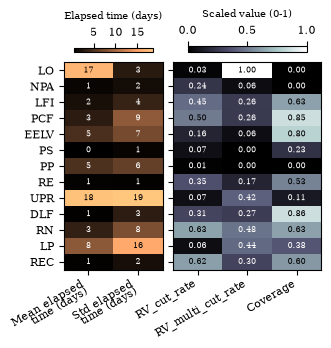

In [20]:
annotate = True
cmap_time = 'copper'
cmap_rate = 'bone'

df = metrics_pp_df_nona.copy()

day_metrics  = ['mean_elapsed_time', 'std_elapsed_time']
rate_metrics = ['RV_got_cut_rate', 'RV_multi_cut_rate', 'coverage']
day_labels   = ['Mean elapsed\ntime (days)', 'Std elapsed\ntime (days)']
rate_labels  = ['RV_cut_rate', 'RV_multi_cut_rate', 'Coverage']

# --- Aggregate to group level (mean of each metric) ---------
df['_group'] = [get_politician2party()[n] for n in df.index]
df = df.groupby('_group')[day_metrics + rate_metrics].mean()

group_order = [p for p in party_colors if p in df.index]
df = df.loc[group_order]
parties = list(df.index)
n = len(df.index)

# --- Days: seconds -> days -----------------------------------
day_raw = df[day_metrics].to_numpy() / 86400.0
vmin_d, vmax_d = np.nanmin(day_raw), np.nanmax(day_raw)   # shared day scale

# --- Rates: 0-1 ---------------------------------------------
rate_data = df[rate_metrics].to_numpy()

# --- Plot: two panels sharing y -----------------------------
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(column_width, column_width), sharey=True,
    gridspec_kw={'width_ratios': [len(day_metrics), len(rate_metrics)], 'wspace': 0.08}
)

# LEFT: days, coloured on shared day scale, annotated with real days
imL = axL.imshow(day_raw, aspect='auto', cmap=cmap_time, vmin=vmin_d, vmax=vmax_d)
axL.set_xticks(np.arange(len(day_metrics)))
axL.set_xticklabels(day_labels, rotation=30, ha='right', linespacing=0.75)
axL.set_yticks(np.arange(n))
axL.set_yticklabels(parties, fontsize=8)

# RIGHT: rates 0-1
imR = axR.imshow(rate_data, aspect='auto', cmap=cmap_rate, vmin=0, vmax=1)
axR.set_xticks(np.arange(len(rate_metrics)))
axR.set_xticklabels(rate_labels, rotation=30, ha='right', linespacing=0.75)

if annotate:
    mid_d = (vmin_d + vmax_d) / 2
    for i in range(n):
        for j in range(len(day_metrics)):
            v = day_raw[i, j]
            axL.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=6,
                     color='white' if v < mid_d else 'black')
        for j in range(len(rate_metrics)):
            v = rate_data[i, j]
            axR.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                     color='white' if v < 0.5 else 'black')

cbarL = fig.colorbar(imL, ax=axL, shrink=0.8, location='top', pad=0.04)
cbarL.ax.set_title('Elapsed time (days)', fontsize=7, pad=6)

cbarR = fig.colorbar(imR, ax=axR, shrink=0.8, location='top', pad=0.04)
cbarR.ax.set_title('Scaled value (0-1)', fontsize=7, pad=6)

plt.tight_layout()
fig.savefig('Figures/heatmap_upload_patterns.pdf', bbox_inches='tight')
fig.savefig('../00_ARTICLES/69d66ccf1cded16fd8f7b0c2/Figures/heatmap_upload_patterns.pdf', bbox_inches='tight')
plt.show()


In [21]:
get_party_orientation()

{'LO': 'Far Left',
 'NPA': 'Far Left',
 'LFI': 'Left',
 'PCF': 'Left',
 'PS': 'Left',
 'EcoS': 'Left',
 'EELV': 'Left',
 'PP': 'Left',
 'DG': 'Left',
 'RE': 'Center',
 'MoDem': 'Center',
 'UDI': 'Center',
 'HOR': 'Center',
 'UPR': 'Right',
 'LR': 'Right',
 'DD': 'Right',
 'DLF': 'Right',
 'RN': 'Far Right',
 'LP': 'Far Right',
 'REC': 'Far Right',
 'autre': 'Other'}

In [22]:
df.index

Index(['LO', 'NPA', 'LFI', 'PCF', 'EELV', 'PS', 'PP', 'RE', 'UPR', 'DLF', 'RN',
       'LP', 'REC'],
      dtype='str', name='_group')

In [23]:
party_order = party2orientation.keys()

NameError: name 'party2orientation' is not defined

/var/folders/s8/86mtzm812zdfvh1cgg7lh2wh0000gp/T/ipykernel_13710/3980507527.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


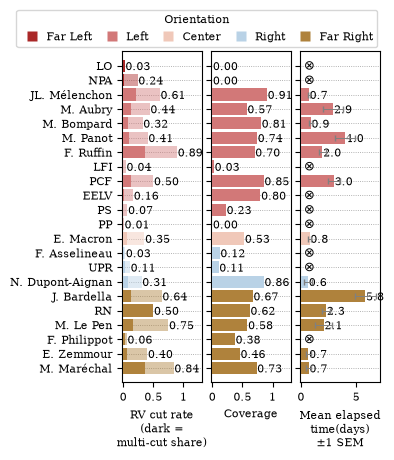

In [24]:
# ---- Per-politician bar plots (replaces heatmap) --------------------------
color_map = get_politic_news_color_maps()

polit2party = get_politician2party()   # <-- ADJUST / VERIFY
party2orientation = get_party_orientation()
df = metrics_pp_df_nona.copy()

# order politicians by orientation (Far Left -> Far Right), then keep stable within group
orient_order = ['Far Left', 'Left', 'Center', 'Right', 'Far Right']
party_order = ['LO', 'NPA', 'LFI', 'PCF', 'EELV', 'PS', 'EcoS', 'PP', 'DG', 'RE', 'MoDem', 'UDI', 'HOR', 'UPR', 'LR', 'DD', 'DLF', 'RN', 'LP', 'REC', 'autre']
df['_party'] = [polit2party[n] for n in df.index]
df['_orient'] = [party2orientation[polit2party[n]] for n in df.index]
df['_party_rank'] = df['_party'].apply(
    lambda o: party_order.index(o) if o in party_order else len(orient_order))
df = df.sort_values('_party_rank')          # remove this line to keep original order

politicians = list(df.index)
abbr = get_politician_abbr_name()
politician_labels = [abbr.get(p, p) for p in politicians]   # parties left unchanged
colors = [color_map[o] for o in df['_orient']]
n = len(politicians)

# ---- edge counts per name (from the graph, matching what you printed) ----
EDGE_THRESH = 24   # names with >= this many edges get an elapsed-time bar; below -> cross
n_edges = np.array([len(gs_pp_only[p].edges()) if p in gs_pp_only else 0
                    for p in politicians])
enough = n_edges >= EDGE_THRESH   # boolean mask; change to > for strictly more than 24

y = np.arange(n)
bar_h = 0.85   # slightly larger bars

fig, axes = plt.subplots(
    1, 3, figsize=(column_width, 0.15 * n + 1), sharey=True,
    gridspec_kw={'wspace': 0.12}   # less space between subplots
)
ax_cut, ax_cov, ax_time = axes   # elapsed time is now the LAST panel

# ---- 1) RV_got_cut_rate, with RV_multi_cut_rate nested (ALL names) ----
got_cut   = df['RV_got_cut_rate'].to_numpy()
multi_cut = df['RV_multi_cut_rate'].to_numpy()          # proportion of CUT rvs
multi_abs = got_cut * np.nan_to_num(multi_cut, nan=0.0) # share of ALL rvs that are multi-cut

ax_cut.barh(y, got_cut, height=bar_h, color=colors, alpha=0.45,
            label='RV cut rate', zorder=3)
ax_cut.barh(y, multi_abs, height=bar_h, color=colors, alpha=1.0,
            label='multi-cut (within cut)', zorder=3)
ax_cut.set_xlabel('RV cut rate\n(dark =\nmulti-cut share)')
ax_cut.set_yticks(y)
ax_cut.set_yticklabels(politician_labels)
ax_cut.invert_yaxis()   # first row on top

for yi, v in enumerate(got_cut):
    if not np.isnan(v):
        ax_cut.text(v + 0.01, yi+0.1, f'{v:.2f}', va='center', ha='left')

# ---- 2) Coverage (ALL names) ----
coverage = df['coverage'].to_numpy()
ax_cov.barh(y, coverage, height=bar_h, color=colors, zorder=3)
ax_cov.set_xlabel('Coverage')

for yi, v in enumerate(coverage):
    if not np.isnan(v):
        ax_cov.text(v + 0.01, yi+0.1, f'{v:.2f}', va='center', ha='left')

# ---- 3) Elapsed time (days), SEM error bar -- only for names with enough edges ----
elapsed_days = df['mean_elapsed_time'].to_numpy() / 86400.0
elapsed_err  = df['sem_elapsed_time'].to_numpy()  / 86400.0

# mask out under-threshold names so no bar is drawn for them
elapsed_days_plot = np.where(enough, elapsed_days, np.nan)
elapsed_err_plot  = np.where(enough, elapsed_err, np.nan)

ax_time.barh(y, elapsed_days_plot, height=bar_h, color=colors,
             xerr=elapsed_err_plot, error_kw=dict(ecolor='0.5', lw=0.7, capsize=2),
             zorder=3)
ax_time.set_xlabel('Mean elapsed\ntime(days)\n±1 SEM')

time_xmax = np.nanmax(elapsed_days_plot + np.nan_to_num(elapsed_err_plot))

# value labels for names with a bar; cross marker near the axis for the rest
for yi in range(n):
    if enough[yi] and not np.isnan(elapsed_days[yi]):
        v, e = elapsed_days[yi], np.nan_to_num(elapsed_err[yi])
        ax_time.text(v + 0.01 * time_xmax, yi+0.1, f'{elapsed_days[yi]:.1f}',
                     va='center', ha='left')
    else:
        ax_time.text(0.04 * time_xmax, yi+0.1, s='$\\otimes$',fontsize=9, va='center', ha='left',color='k')

# ---- x limits ----
ax_time.set_xlim(left=-0.01 * time_xmax)
for ax in (ax_cut, ax_cov):
    ax.set_xlim(-0.02, 1.3)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(['0', '0.5', '1'])

# ---- grey dotted guide lines at each politician row (behind bars) ----
for ax in (ax_cut, ax_cov, ax_time):
    ax.grid(axis='y', linestyle=':', color='0.6', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

ax_time.set_ylim(n, -1)

# ---- orientation legend ----
present = [o for o in orient_order if o in set(df['_orient'])]
legend_handles = [Line2D([0], [0], marker='s', linestyle='', markersize=7,
                         markerfacecolor=color_map[o], markeredgecolor='none', label=o)
                  for o in present]

fig.legend(handles=legend_handles, loc='upper center', ncol=len(present) + 1,
           frameon=True, title='Orientation', bbox_to_anchor=(0.35, 0.99),
           columnspacing=0.8, handletextpad=0.3, borderpad=0.4)

plt.tight_layout()
fig.savefig('Figures/barplots_upload_patterns.pdf', bbox_inches='tight')
fig.savefig('../00_ARTICLES/69d66ccf1cded16fd8f7b0c2/Figures/barplots_upload_patterns.pdf',
            bbox_inches='tight')
plt.show()

In [37]:
from scipy.stats import mannwhitneyu
import numpy as np

challenger_left  = {'LFI', 'Mathilde Panot', 'François Ruffin', 'Manuel Bompard',
                    'Manon Aubry', 'Jean-Luc Mélenchon', 'PCF'}
challenger_right = {'RN', 'Jordan Bardella', 'Marine Le Pen', 'Éric Zemmour', 'Marion Maréchal'}
challenger = challenger_left | challenger_right

eelv = {'EELV'}                       # weakest challenger, excluded from the test

left  = {'LFI','Mathilde Panot','François Ruffin','Manuel Bompard','Manon Aubry',
         'Jean-Luc Mélenchon','PCF','PS','EELV','LO','NPA'}
right = {'RN','Jordan Bardella','Marine Le Pen','Éric Zemmour','Marion Maréchal',
         'Florian Philippot','Nicolas Dupont-Aignan','François Asselineau','UPR'}

df = metrics_pp_df_nona.copy()
df = df[~df.index.isin(eelv)]
rate_col = 'RV_got_cut_rate'          # confirm this is the column name in your frame

def run(mask_a, mask_b, label):
    a = df.loc[df.index.isin(mask_a), rate_col].dropna().to_numpy()
    b = df.loc[df.index.isin(mask_b), rate_col].dropna().to_numpy()
    U, p = mannwhitneyu(a, b, alternative='two-sided')
    r = 2*U/(len(a)*len(b)) - 1        # +ve => group A ranks higher
    print(f"{label}: U={U:.0f}, n1={len(a)}, n2={len(b)}, p={p:.4f}, "
          f"rank-biserial r={r:.2f}, medians {np.median(a):.2f} vs {np.median(b):.2f}")
    return set(mask_a) - set(df.index)  # names that didn't match, to catch typos

miss = run(challenger, set(df.index) - challenger - eelv, "challenger vs rest")
print("challenger names not found in df:", miss)
run(left, right, "left vs right")

# robustness: move far-left LO/NPA into challenger, re-test
run(challenger | {'LO','NPA'}, set(df.index) - challenger - eelv - {'LO','NPA'},
    "challenger+farleft vs rest")

challenger vs rest: U=101, n1=12, n2=9, p=0.0009, rank-biserial r=0.87, medians 0.50 vs 0.07
challenger names not found in df: set()
left vs right: U=40, n1=10, n2=9, p=0.7439, rank-biserial r=-0.10, medians 0.36 vs 0.40
challenger+farleft vs rest: U=84, n1=14, n2=7, p=0.0100, rank-biserial r=0.71, medians 0.47 vs 0.07


set()

# NM

In [38]:
metrics_nm = create_metrics_df(df_yt = yt_nm_videos_2024, df_tt = tt_nm_videos_2024, gs = gs_news_only, 
                            name_standard_list=nm_name_standard_list, FILL_NA = False)

In [39]:
metrics_nm_df = pd.DataFrame.from_dict(metrics_nm).T
metrics_nm_df_nona = metrics_nm_df.dropna()

/var/folders/s8/86mtzm812zdfvh1cgg7lh2wh0000gp/T/ipykernel_13710/3400355851.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


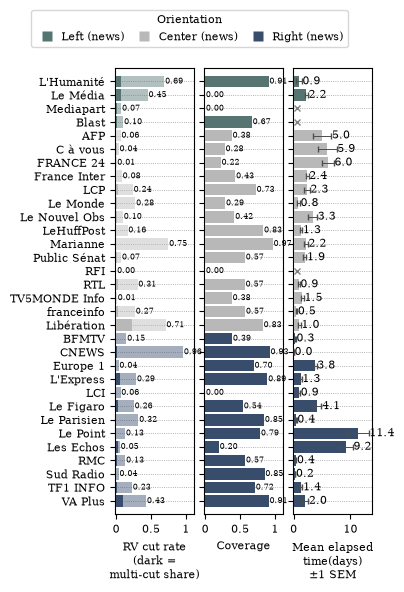

In [40]:
# ---- Per-news-media bar plots ----------------------------------------------
color_map = get_politic_news_color_maps()

nm2orientation = get_news_channel_orientation()
df = metrics_nm_df_nona.copy()

# order = order of keys in get_news_channel_orientation(), keep only present rows
nm_order = [n for n in nm2orientation.keys() if n in df.index]
df = df.loc[nm_order]

channels = list(df.index)
colors = [color_map[nm2orientation[c]] for c in channels]
n = len(channels)

# ---- edge counts per channel (from the graph) ----
EDGE_THRESH = 24   # channels with >= this many edges get an elapsed-time bar; below -> cross
n_edges = np.array([len(gs_news_only[c].edges()) if c in gs_news_only else 0
                    for c in channels])
enough = n_edges >= EDGE_THRESH

y = np.arange(n)
bar_h = 0.85

fig, axes = plt.subplots(
    1, 3, figsize=(column_width, 0.15 * n + 1), sharey=True,
    gridspec_kw={'wspace': 0.12}
)
ax_cut, ax_cov, ax_time = axes   # elapsed time last, as in the politician figure

# ---- 1) RV_got_cut_rate, RV_multi_cut_rate nested ----
got_cut   = df['RV_got_cut_rate'].to_numpy()
multi_cut = df['RV_multi_cut_rate'].to_numpy()
multi_abs = got_cut * np.nan_to_num(multi_cut, nan=0.0)

ax_cut.barh(y, got_cut, height=bar_h, color=colors, alpha=0.45,
            label='RV cut rate', zorder=3)
ax_cut.barh(y, multi_abs, height=bar_h, color=colors, alpha=1.0,
            label='multi-cut (within cut)', zorder=3)
ax_cut.set_xlabel('RV cut rate\n(dark =\nmulti-cut share)')
ax_cut.set_yticks(y)
ax_cut.set_yticklabels(channels)
ax_cut.invert_yaxis()

for yi, v in enumerate(got_cut):
    if not np.isnan(v):
        ax_cut.text(v + 0.01, yi, f'{v:.2f}', va='center', ha='left', fontsize=6)

# ---- 2) Coverage ----
coverage = df['coverage'].to_numpy()
ax_cov.barh(y, coverage, height=bar_h, color=colors, zorder=3)
ax_cov.set_xlabel('Coverage')

for yi, v in enumerate(coverage):
    if not np.isnan(v):
        ax_cov.text(v + 0.01, yi, f'{v:.2f}', va='center', ha='left', fontsize=6)

# ---- 3) Elapsed time (days), SEM error bar, only for channels with enough edges ----
elapsed_days = df['mean_elapsed_time'].to_numpy() / 86400.0
elapsed_err  = df['sem_elapsed_time'].to_numpy()  / 86400.0
elapsed_days_plot = np.where(enough, elapsed_days, np.nan)
elapsed_err_plot  = np.where(enough, elapsed_err, np.nan)

ax_time.barh(y, elapsed_days_plot, height=bar_h, color=colors,
             xerr=elapsed_err_plot, error_kw=dict(ecolor='0.3', lw=0.7, capsize=2),
             zorder=3)
ax_time.set_xlabel('Mean elapsed\ntime(days)\n±1 SEM')

time_xmax = np.nanmax(elapsed_days_plot + np.nan_to_num(elapsed_err_plot))

for yi in range(n):
    if enough[yi] and not np.isnan(elapsed_days[yi]):
        v, e = elapsed_days[yi], np.nan_to_num(elapsed_err[yi])
        ax_time.text(v + e + 0.01 * time_xmax, yi, f'{elapsed_days[yi]:.1f}',
                     va='center', ha='left')
    else:
        ax_time.plot(0.04 * time_xmax, yi, marker='x', color='0.5',
                     markersize=5, markeredgewidth=1.0, zorder=4)

# ---- x limits ----
ax_time.set_xlim(left=-0.01 * time_xmax)
for ax in (ax_cut, ax_cov):
    ax.set_xlim(-0.02, 1.12)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(['0', '0.5', '1'])

# ---- grey dotted guide lines ----
for ax in (ax_cut, ax_cov, ax_time):
    ax.grid(axis='y', linestyle=':', color='0.6', linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)

ax_time.set_ylim(n, -1)

# ---- orientation legend ----
present = [o for o in ['Left (news)', 'Center (news)', 'Right (news)']
          if o in set(nm2orientation[c] for c in channels)]
legend_handles = [Line2D([0], [0], marker='s', linestyle='', markersize=7,
                         markerfacecolor=color_map[o], markeredgecolor='none', label=o)
                  for o in present]
fig.legend(handles=legend_handles, loc='upper center', ncol=len(present),
           frameon=True, title='Orientation', bbox_to_anchor=(0.35, 0.99),
           columnspacing=0.8, handletextpad=0.3, borderpad=0.4)

plt.tight_layout()
fig.savefig('Figures/barplots_upload_patterns_nm.pdf', bbox_inches='tight')
fig.savefig('../00_ARTICLES/69d66ccf1cded16fd8f7b0c2/Figures/barplots_upload_patterns_nm.pdf',
            bbox_inches='tight')
plt.show()

/var/folders/s8/86mtzm812zdfvh1cgg7lh2wh0000gp/T/ipykernel_13710/1473380117.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


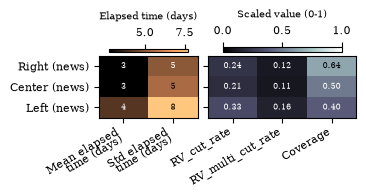

In [41]:
annotate = True
cmap_time = 'copper'
cmap_rate = 'bone'

df = metrics_nm_df_nona.copy()

day_metrics  = ['mean_elapsed_time', 'std_elapsed_time']
rate_metrics = ['RV_got_cut_rate', 'RV_multi_cut_rate', 'coverage']
day_labels   = ['Mean elapsed\ntime (days)', 'Std elapsed\ntime (days)']
rate_labels  = ['RV_cut_rate', 'RV_multi_cut_rate', 'Coverage']

# --- Aggregate to group level (mean of each metric) ---------
df['_group'] = [get_news_channel_orientation()[n] for n in df.index]
df = df.groupby('_group')[day_metrics + rate_metrics].mean()

group_order = [o for o in ['Right (news)', 'Center (news)', 'Left (news)'] if o in df.index]
df = df.loc[group_order]
orientations = list(df.index)
n = len(df.index)

# --- Days: seconds -> days -----------------------------------
day_raw = df[day_metrics].to_numpy() / 86400.0
vmin_d, vmax_d = np.nanmin(day_raw), np.nanmax(day_raw)   # shared day scale

# --- Rates: 0-1 ---------------------------------------------
rate_data = df[rate_metrics].to_numpy()

# --- Plot: two panels sharing y -----------------------------
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(column_width, 0.3*column_width), sharey=True,
    gridspec_kw={'width_ratios': [len(day_metrics), len(rate_metrics)], 'wspace': 0.08}
)

# LEFT: days, coloured on shared day scale, annotated with real days
imL = axL.imshow(day_raw, aspect='auto', cmap=cmap_time, vmin=vmin_d, vmax=vmax_d)
axL.set_xticks(np.arange(len(day_metrics)))
axL.set_xticklabels(day_labels, rotation=30, ha='right', linespacing=0.75)
axL.set_yticks(np.arange(n))
axL.set_yticklabels(orientations, fontsize=8)

# RIGHT: rates 0-1
imR = axR.imshow(rate_data, aspect='auto', cmap=cmap_rate, vmin=0, vmax=1)
axR.set_xticks(np.arange(len(rate_metrics)))
axR.set_xticklabels(rate_labels, rotation=30, ha='right', linespacing=0.75)

if annotate:
    mid_d = (vmin_d + vmax_d) / 2
    for i in range(n):
        for j in range(len(day_metrics)):
            v = day_raw[i, j]
            axL.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=6,
                     color='white' if v < mid_d else 'black')
        for j in range(len(rate_metrics)):
            v = rate_data[i, j]
            axR.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                     color='white' if v < 0.5 else 'black')

cbarL = fig.colorbar(imL, ax=axL, shrink=0.8, location='top', pad=0.04)
cbarL.ax.set_title('Elapsed time (days)', fontsize=7, pad=6)

cbarR = fig.colorbar(imR, ax=axR, shrink=0.8, location='top', pad=0.04)
cbarR.ax.set_title('Scaled value (0-1)', fontsize=7, pad=6)

plt.tight_layout()
fig.savefig('Figures/heatmap_upload_patterns_nm.pdf', bbox_inches='tight')
fig.savefig('../00_ARTICLES/69d66ccf1cded16fd8f7b0c2/Figures/heatmap_upload_patterns_nm.pdf', bbox_inches='tight')
plt.show()


In [42]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- 4 metrics for PCA (confirmed) ---
pca_metrics = ['mean_elapsed_time', 'RV_got_cut_rate', 'RV_multi_cut_rate', 'coverage']

df_pca = metrics_nm_df_nona.copy()
df_pca = df_pca.loc[[n for n in nm2orientation.keys() if n in df_pca.index]]

# drop channels with any NaN in the 4 metrics (RV_multi_cut_rate is the usual culprit)
n_before = len(df_pca)
df_pca = df_pca.dropna(subset=pca_metrics)
n_dropped = n_before - len(df_pca)
if n_dropped > 0:
    print(f"Dropped {n_dropped} channel(s) with NaN in PCA metrics.")

X = df_pca[pca_metrics].to_numpy(dtype=np.float64)

# standardize so mean_elapsed_time (seconds) doesn't dominate
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))
print("\nLoadings:")
for m, c1, c2 in zip(pca_metrics, pca.components_[0], pca.components_[1]):
    print(f"{m:>22} PC1={c1:+.2f}  PC2={c2:+.2f}")

pca_channels = list(df_pca.index)

Explained variance ratio (PC1, PC2): [0.49638531 0.25462958]
Cumulative: [0.49638531 0.75101489]

Loadings:
     mean_elapsed_time PC1=-0.54  PC2=+0.28
       RV_got_cut_rate PC1=+0.55  PC2=+0.43
     RV_multi_cut_rate PC1=-0.34  PC2=+0.79
              coverage PC1=+0.54  PC2=+0.34


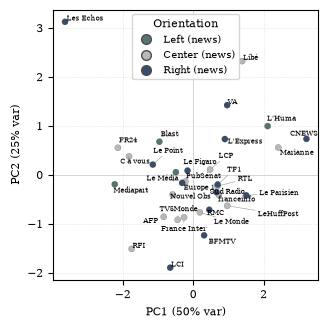

In [43]:
from adjustText import adjust_text

nm_abbr_name = {"Libération":"Libé",
"VA Plus":"VA",
"L'Humanité":"L'Huma",
"FRANCE 24":"FR24",
"TF1 INFO":"TF1",
"Public Sénat":"PubSénat",
"Le Nouvel Obs":"Nouvel Obs",
"TV5MONDE Info":"TV5Monde"}

fig, ax = plt.subplots(figsize=(column_width, column_width))

pc1, pc2 = X_reduced[:, 0], X_reduced[:, 1]
dot_colors = [color_map[nm2orientation[c]] for c in pca_channels]

ax.scatter(pc1, pc2, c=dot_colors, s=20, edgecolor='k', linewidth=0.1, zorder=3)

# labels (abbreviated where listed), then let adjustText push them apart
texts = [ax.text(xi, yi, nm_abbr_name.get(name, name), fontsize=5, zorder=4)
         for xi, yi, name in zip(pc1, pc2, pca_channels)]
adjust_text(texts, ax=ax,
            arrowprops=dict(arrowstyle='-', color='0.6', lw=0.4))

ev = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({ev[0]*100:.0f}% var)')
ax.set_ylabel(f'PC2 ({ev[1]*100:.0f}% var)')
ax.axhline(0, color='0.8', linewidth=0.6, zorder=0)
ax.axvline(0, color='0.8', linewidth=0.6, zorder=0)
ax.grid(True, linestyle=':', color='0.85', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# orientation legend
present = [o for o in ['Left (news)', 'Center (news)', 'Right (news)']
          if o in set(nm2orientation[c] for c in pca_channels)]
legend_handles = [Line2D([0], [0], marker='o', linestyle='', markersize=7,
                         markerfacecolor=color_map[o], markeredgecolor='0.3', label=o)
                  for o in present]
ax.legend(handles=legend_handles, title='Orientation', frameon=True,
          fontsize=7, loc='best')

plt.tight_layout()
fig.savefig('Figures/pca_nm_posting_behavior.pdf', bbox_inches='tight')
fig.savefig('../00_ARTICLES/69d66ccf1cded16fd8f7b0c2/Figures/pca_nm_posting_behavior.pdf',
            bbox_inches='tight')
plt.show()

In [48]:
df_pp.index

Index(['Mathilde Panot', 'EELV', 'LO', 'LFI', 'François Ruffin',
       'Marion Maréchal', 'Florian Philippot', 'François Asselineau', 'PS',
       'Manuel Bompard', 'NPA', 'Éric Zemmour', 'Nicolas Dupont-Aignan', 'PP',
       'UPR', 'RN', 'Manon Aubry', 'Marine Le Pen', 'Jean-Luc Mélenchon',
       'Emmanuel Macron', 'Jordan Bardella', 'PCF'],
      dtype='str')

In [51]:
# ---- Combined group table: PP (active/inactive) vs NM (L/C/R) --------------
report_metrics = ['mean_elapsed_time', 'RV_got_cut_rate', 'RV_multi_cut_rate', 'coverage']
challenger = ['Mathilde Panot', 'EELV','LFI', 'François Ruffin', 'Marion Maréchal', 
       'Manuel Bompard', 'Éric Zemmour',  'RN', 'Manon Aubry', 'Marine Le Pen', 'Jean-Luc Mélenchon',
       'Jordan Bardella', 'PCF']
other = [ 'LO', 'Florian Philippot', 'François Asselineau', 'PS','NPA','Nicolas Dupont-Aignan', 'PP',
       'UPR', 'Emmanuel Macron', ]

# --- politicians: split into active / not active ---
df_pp = metrics_pp_df_nona.copy()
df_pp['mean_elapsed_time_days'] = df_pp['mean_elapsed_time'] / 86400.0
pp_active_mask = df_pp.index.isin(challenger)
df_pp['_group'] = np.where(pp_active_mask, 'PP challenger', 'PP other')

# --- news media: group by orientation ---
df_nm = metrics_nm_df_nona.copy()
df_nm = df_nm.loc[[n for n in nm2orientation.keys() if n in df_nm.index]]
df_nm['mean_elapsed_time_days'] = df_nm['mean_elapsed_time'] / 86400.0
df_nm['_group'] = [nm2orientation[c] for c in df_nm.index]

# --- combine ---
agg_metrics = ['mean_elapsed_time_days', 'RV_got_cut_rate', 'RV_multi_cut_rate', 'coverage']
combined = pd.concat([
    df_pp[['_group'] + agg_metrics],
    df_nm[['_group'] + agg_metrics],
])

# unweighted mean per group; NaN skipped by .mean() (e.g. multi-cut with 0 cut RVs)
grouped = combined.groupby('_group')
tab = grouped[agg_metrics].mean()
tab['n'] = grouped.size()

row_order = ['PP challenger', 'PP other', 'Left (news)', 'Center (news)', 'Right (news)']
tab = tab.loc[[g for g in row_order if g in tab.index]]

tab = tab.rename(columns={
    'mean_elapsed_time_days': 'Elapsed time (days)',
    'RV_got_cut_rate':        'RV cut rate',   # NOTE: circular for the two PP groups (split is on this)
    'RV_multi_cut_rate':      'Multi-cut rate (of cut)',
    'coverage':               'Coverage',
    'n':                      'N',
})

disp = tab.copy()
disp['Elapsed time (days)'] = disp['Elapsed time (days)'].round(1)
for col in ['RV cut rate', 'Multi-cut rate (of cut)', 'Coverage']:
    disp[col] = disp[col].round(2)
disp['N'] = disp['N'].astype(int)

In [52]:
for row in disp.iterrows():
    print(f"{row[0]} & {row[1]['Elapsed time (days)']} & {row[1]['RV cut rate']} & {row[1]['Multi-cut rate (of cut)']}& {row[1]['Coverage']}& {row[1]['N']} \\\\")


    

PP challenger & 2.4 & 0.5 & 0.3& 0.65& 13.0 \\
PP other & 7.7 & 0.13 & 0.31& 0.25& 9.0 \\
Left (news) & 4.1 & 0.33 & 0.16& 0.4& 4.0 \\
Center (news) & 2.7 & 0.21 & 0.11& 0.5& 15.0 \\
Right (news) & 2.7 & 0.24 & 0.12& 0.64& 13.0 \\
